In [20]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
import yaml
import cv2

In [13]:
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [14]:
future_frames = config['data']['future_frames']
image_folder = config['data']['frames_folder']
detections_folder = config['data']['detections_folder']


In [15]:
frames = sorted(Path(image_folder).glob('*.jpg'))

In [16]:
pairs = []
i = 0
while i < 2:  # Try to find 10 valid pairs
    choice = random.randint(0, len(frames) - 2)
    images = [] 
    for offset in future_frames:
        if choice + offset < len(frames):
            images.append(frames[choice + offset])
        else:
            print(f"Skipping offset {offset} for choice {choice} because it exceeds frame count")
    pairs.append(images)
    i += 1

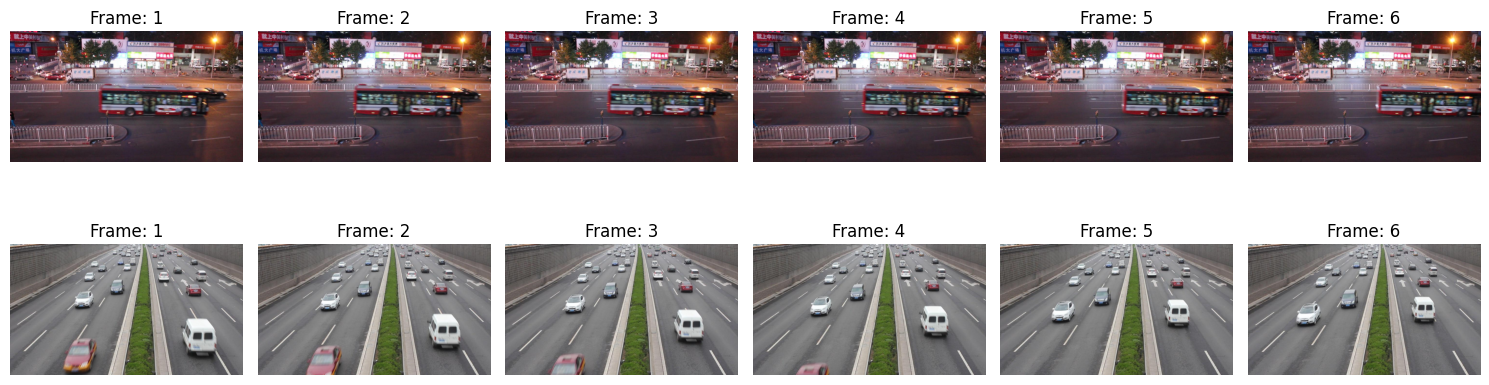

In [17]:
fig, axes = plt.subplots(len(pairs), len(future_frames), figsize=(15, 5))
for pair in pairs:
    for idx, img_path in enumerate(pair):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[pairs.index(pair), idx].imshow(img)
        axes[pairs.index(pair), idx].set_title(f"Frame: {idx%len(future_frames) + 1}")
        axes[pairs.index(pair), idx].axis('off')
plt.tight_layout()
plt.show()
    

In [18]:
def compute_iou(box_a, box_b):
    xA = max(box_a[0], box_b[0])
    yA = max(box_a[1], box_b[1])
    xB = min(box_a[2], box_b[2])
    yB = min(box_a[3], box_b[3])
    
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)
    
    boxAArea = (box_a[2] - box_a[0] + 1) * (box_a[3] - box_a[1] + 1)
    boxBArea = (box_b[2] - box_b[0] + 1) * (box_b[3] - box_b[1] + 1)
    
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou


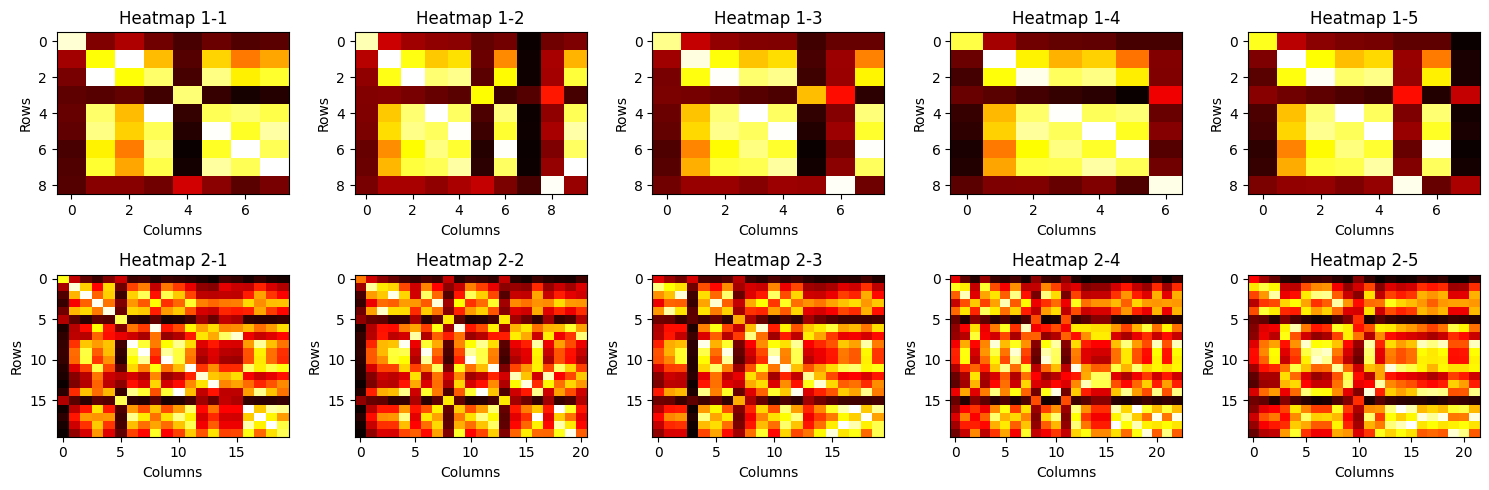

In [29]:
detections = []
for pair in pairs:
    detections_for_pair = []
    for img_path in pair:
        detection_file = Path(detections_folder) / img_path.with_suffix('.txt').name
        if detection_file.exists():
            detection = np.loadtxt(detection_file, delimiter=' ')
            detections_for_pair.append(detection)
    detections.append(detections_for_pair)

matrices = []
for idx, full_det in enumerate(detections):
    base = full_det[0]
    cur_matrices = []
    for det in full_det[1:]:
        IoU_matrix = np.zeros((len(base), len(det)))
        for i in range(len(base)):
            for j in range(len(det)):
                IoU_matrix[i, j] = compute_iou(base[i][1:], det[j][1:])
        cur_matrices.append(IoU_matrix)
    matrices.append(cur_matrices)

fig, axes = plt.subplots(len(matrices), len(matrices[0]), figsize=(15, 5))
for i, row in enumerate(matrices):
    for j, IoU_matrix in enumerate(row):
        axes[i, j].imshow(IoU_matrix, cmap="hot", aspect="auto")
        axes[i, j].set_title(f"Heatmap {i+1}-{j+1}")
        axes[i, j].set_xlabel("Columns")
        axes[i, j].set_ylabel("Rows")
plt.tight_layout()
plt.show()